In [22]:
from sklearn.metrics import log_loss, roc_auc_score
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from __future__ import annotations
from pathlib import Path
from typing import Union
import xgboost as xgb
from xgboost import XGBClassifier

In [23]:
'''dfs = [pd.read_parquet(f) for f in glob.glob("data/matches/*.parquet")]
match_df = dfs[np.random.randint(len(dfs))]'''

'dfs = [pd.read_parquet(f) for f in glob.glob("data/matches/*.parquet")]\nmatch_df = dfs[np.random.randint(len(dfs))]'

In [24]:
data = pd.read_parquet("data/processed/data_processed.parquet")

In [25]:
rand_id = (data['match_id'].unique())[np.random.randint(len(data['match_id'].unique()))]
#rand_id = '2023-usopen-1131'
match_df = data[data['match_id'] == rand_id]
display(match_df)

,match_id,SetNo,GameNo,PointNumber,point_idx,perspective,server_is_persp,pts_in_game_for,pts_in_game_against,games_in_set_for,...,best_of,sets_needed_to_win,is_tiebreak,is_game_point_for,is_game_point_against,is_break_point,ttl_diff,aces_diff,df_diff,y_match
1005922,2014-wimbledon-2401,1,1,0,1,False,False,0,0,0,...,5,3,False,False,False,False,0,0,0,False
1005923,2014-wimbledon-2401,1,1,1,2,False,True,0,0,0,...,5,3,False,False,False,False,0,0,0,False
1005924,2014-wimbledon-2401,1,1,2,3,False,True,1,0,0,...,5,3,False,False,False,False,1,0,0,False
1005925,2014-wimbledon-2401,1,1,3,4,False,True,1,1,0,...,5,3,False,False,False,False,0,0,0,False
1005926,2014-wimbledon-2401,1,1,4,5,False,True,1,2,0,...,5,3,False,False,False,False,-1,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1006237,2014-wimbledon-2401,2,12,155,156,True,False,1,0,6,...,5,3,False,False,False,False,2,-1,-1,True
1006238,2014-wimbledon-2401,2,12,156,157,True,False,2,0,6,...,5,3,False,False,False,False,3,-1,-1,True
1006239,2014-wimbledon-2401,2,12,157,158,True,False,2,1,6,...,5,3,False,False,False,False,2,-1,-1,True
1006240,2014-wimbledon-2401,2,12,158,159,True,False,2,2,6,...,5,3,False,False,False,False,1,-1,-1,True


In [26]:
def draw_set_boundary_markers(
    ax,
    match_df,
    set_col='SetNo',
    perspective_col='perspective',
    p1_value='P1',
    p2_value='P2',
    color='k',
    lw=0.8,
    alpha=0.3,
    ls_p1='--',
    ls_p2=':'
):
    """Draw vertical lines where a set finishes (SetNo changes).

    - If `perspective` exists, marks P1 boundaries with ls_p1 and P2 with ls_p2.
    - If there’s no `perspective` column, treats the whole DataFrame as one series.
    Returns (p1_lines, p2_lines) with the indices used for the markers.
    """

    def _indices_of_set_changes(s):
        vals = s.to_numpy()
        if len(vals) == 0:
            return []
        # positions where SetNo changes: i+1 is the first point of the next set
        return (np.where(np.diff(vals) != 0)[0] + 1).tolist()

    if perspective_col in match_df.columns:
        p1 = match_df[match_df[perspective_col] == p1_value].reset_index(drop=True)
        p2 = match_df[match_df[perspective_col] == p2_value].reset_index(drop=True)
    else:
        p1, p2 = match_df.reset_index(drop=True), None

    p1_lines = _indices_of_set_changes(p1[set_col]) if set_col in p1.columns else []
    p2_lines = _indices_of_set_changes(p2[set_col]) if (p2 is not None and set_col in p2.columns) else []

    for xi in p1_lines:
        ax.axvline(x=xi, color=color, linestyle=ls_p1, linewidth=lw, alpha=alpha)
    for xi in p2_lines:
        ax.axvline(x=xi, color=color, linestyle=ls_p2, linewidth=lw, alpha=alpha)

    return p1_lines, p2_lines


In [27]:
def predict_win_probability(match_df, rand_id, model, feature_cols, names):
    matches = data['match_id'].unique()
    train_ids = set(np.random.choice(matches, size=int(0.8*len(matches)), replace=False))
    train_data = data[data['match_id'].isin(train_ids)]
    test_data  = data[~data['match_id'].isin(train_ids)]
    X_train, y_train = train_data[feature_cols], train_data['y_match']
    X_test,  y_test  = test_data[feature_cols],  test_data['y_match']
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    print("Log Loss:", log_loss(y_test, y_pred_prob))
    print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

    win_prob = []
    for _,point in match_df.iterrows():
        X_point = point[feature_cols].values.reshape(1, -1)
        prob = model.predict_proba(X_point)[0, 1]  # probability Player 1 wins match
        win_prob.append(prob)

    plt.plot(win_prob[:len(win_prob)//2], label='Win Probability (Player 1)')
    plt.xlabel('Point Index')
    plt.ylabel('Probability Player Wins Match')

    plt.plot(win_prob[len(win_prob)//2:], label='Win Probability (Player 2)')
    plt.title(f'Live Win Probability Prediction (Match ID: {rand_id}, Model: {names})')
    plt.ylim(0, 1)
    plt.legend()
    ax = plt.gca()
    draw_set_boundary_markers(ax, match_df)  # adds '--' for P1 and ':' for P2

    plt.show()



Log Loss: 0.49773762216553735
ROC AUC: 0.833411443477756


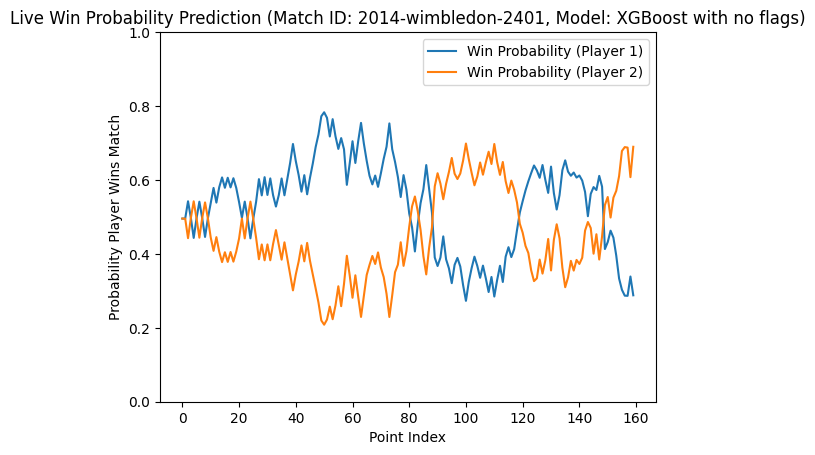

Log Loss: 0.5494131030801966
ROC AUC: 0.7912713350000236


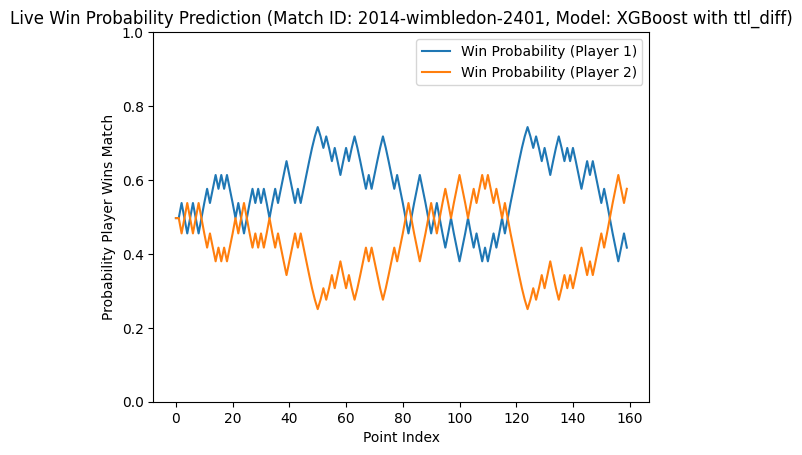

Log Loss: 0.49994805100752576
ROC AUC: 0.834963265674238


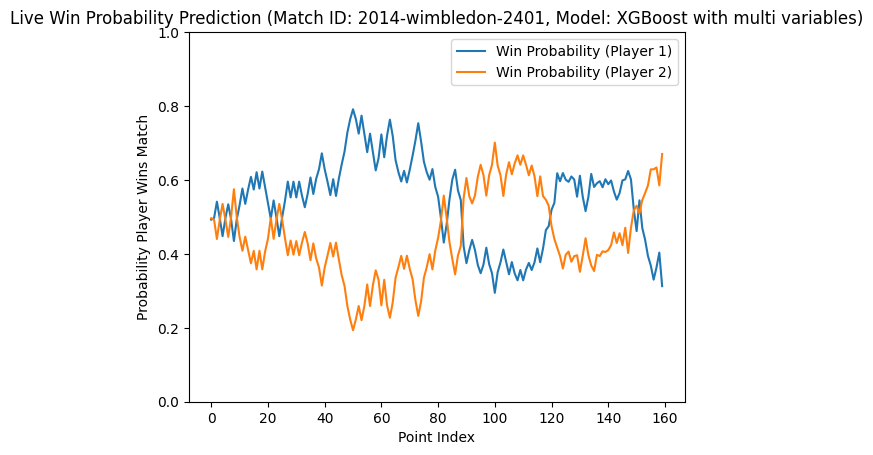

In [28]:
model_df = pd.read_parquet("model_data.parquet", engine="pyarrow")
for i in range(len(model_df)):
    model = XGBClassifier()
    model.load_model(model_df['model_path'][i])
    feature_cols = model_df['input_columns'][i].split('$')
    predict_win_probability(match_df, rand_id, model, feature_cols, model_df['model_desc'][i])